In [1]:
using Plots
using LaTeXStrings
using NCDatasets
using Interpolations
using TimeZones
using Dates
include("src/solar_insolation.jl")
using .SolarInsolationModel

In [2]:
# Plot Settings
plot_font = "Computer Modern"
default(
    fontfamily=plot_font,
    linewidth=2
)

# Vehicle Parameters

In [3]:
# Vehicle Parameters
Base.@kwdef struct ASV_Params
    b_max::Float32 = 6500; # max soc in Wh
    b_min::Float32 = 0; # min soc in Wh
    panel_area::Float32 = 4; # m^2
    panel_efficiency::Float32 = 0.25; # 25% panel efficiency
    v_max::Float32 = 2.315; # max boat speed in m/s 
    v_min::Float32 = 0; # min boat speed in m/s

    k_h::Float32 = 10; # Hotel Load
    k_m::Float32 = 83; # Motor multiplier, need to tune
end

boat = ASV_Params();

# Environment Parameters
dayOfYear = 288; # corresponds to October 15th
lat = 35.45; # degrees - corresponds to Jordan Lake
Δt = 0.1; # time step in hours
t = 0:Δt:24;
og_time = t;
# t = t .+ 12;
# t = t .% 24; # time over a day from noon to noon
n = length(t);

# Initial Conditions
b_0 = boat.b_max;

In [4]:
# ============================================================
function compute_lcbf()
    ϵ₋ = zeros(n); # energy deficit
    Ps = zeros(n);
    for i = 1:n
        Ps[i] = max(0, SolarInsolation(dayOfYear, t[i], lat))*1000* boat.panel_area * boat.panel_efficiency;
        ϵ₋[i] = boat.k_h*(og_time[i] - og_time[1]) - sum(Ps[1:i]*Δt);
    end
    
    
    lcbf = zeros(n);
    
    for i = 1:n
        ϵ₋dag = ϵ₋ .- ϵ₋[i];
        lcbf[i] = max(0, maximum(ϵ₋dag[i:end]));
    end

    return lcbf
end

compute_lcbf (generic function with 1 method)

In [5]:
function compute_ucbf()
    ϵ₊ = zeros(n); # energy surplus
    Ps = zeros(n);
    for i = 1:n
        Ps[i] = max(0, SolarInsolation(dayOfYear, t[i], lat))*1000* boat.panel_area * boat.panel_efficiency;
        # boat.k_h*(og_time[i] - og_time[1])
        ϵ₊[i] = sum(Ps[1:i]*Δt) - (boat.k_h + boat.k_m*(boat.v_max^3))*(og_time[i] - og_time[1]);
    end

    ucbf = zeros(n);

    for i = 1:n
        ϵ₊dag = ϵ₊ .- ϵ₊[i];
        ucbf[i] = boat.b_max - max(0, maximum(ϵ₊dag[i:end]));
    end

    return ucbf
end

compute_ucbf (generic function with 1 method)

In [6]:
lcbf = compute_lcbf();

In [7]:
ucbf = compute_ucbf();

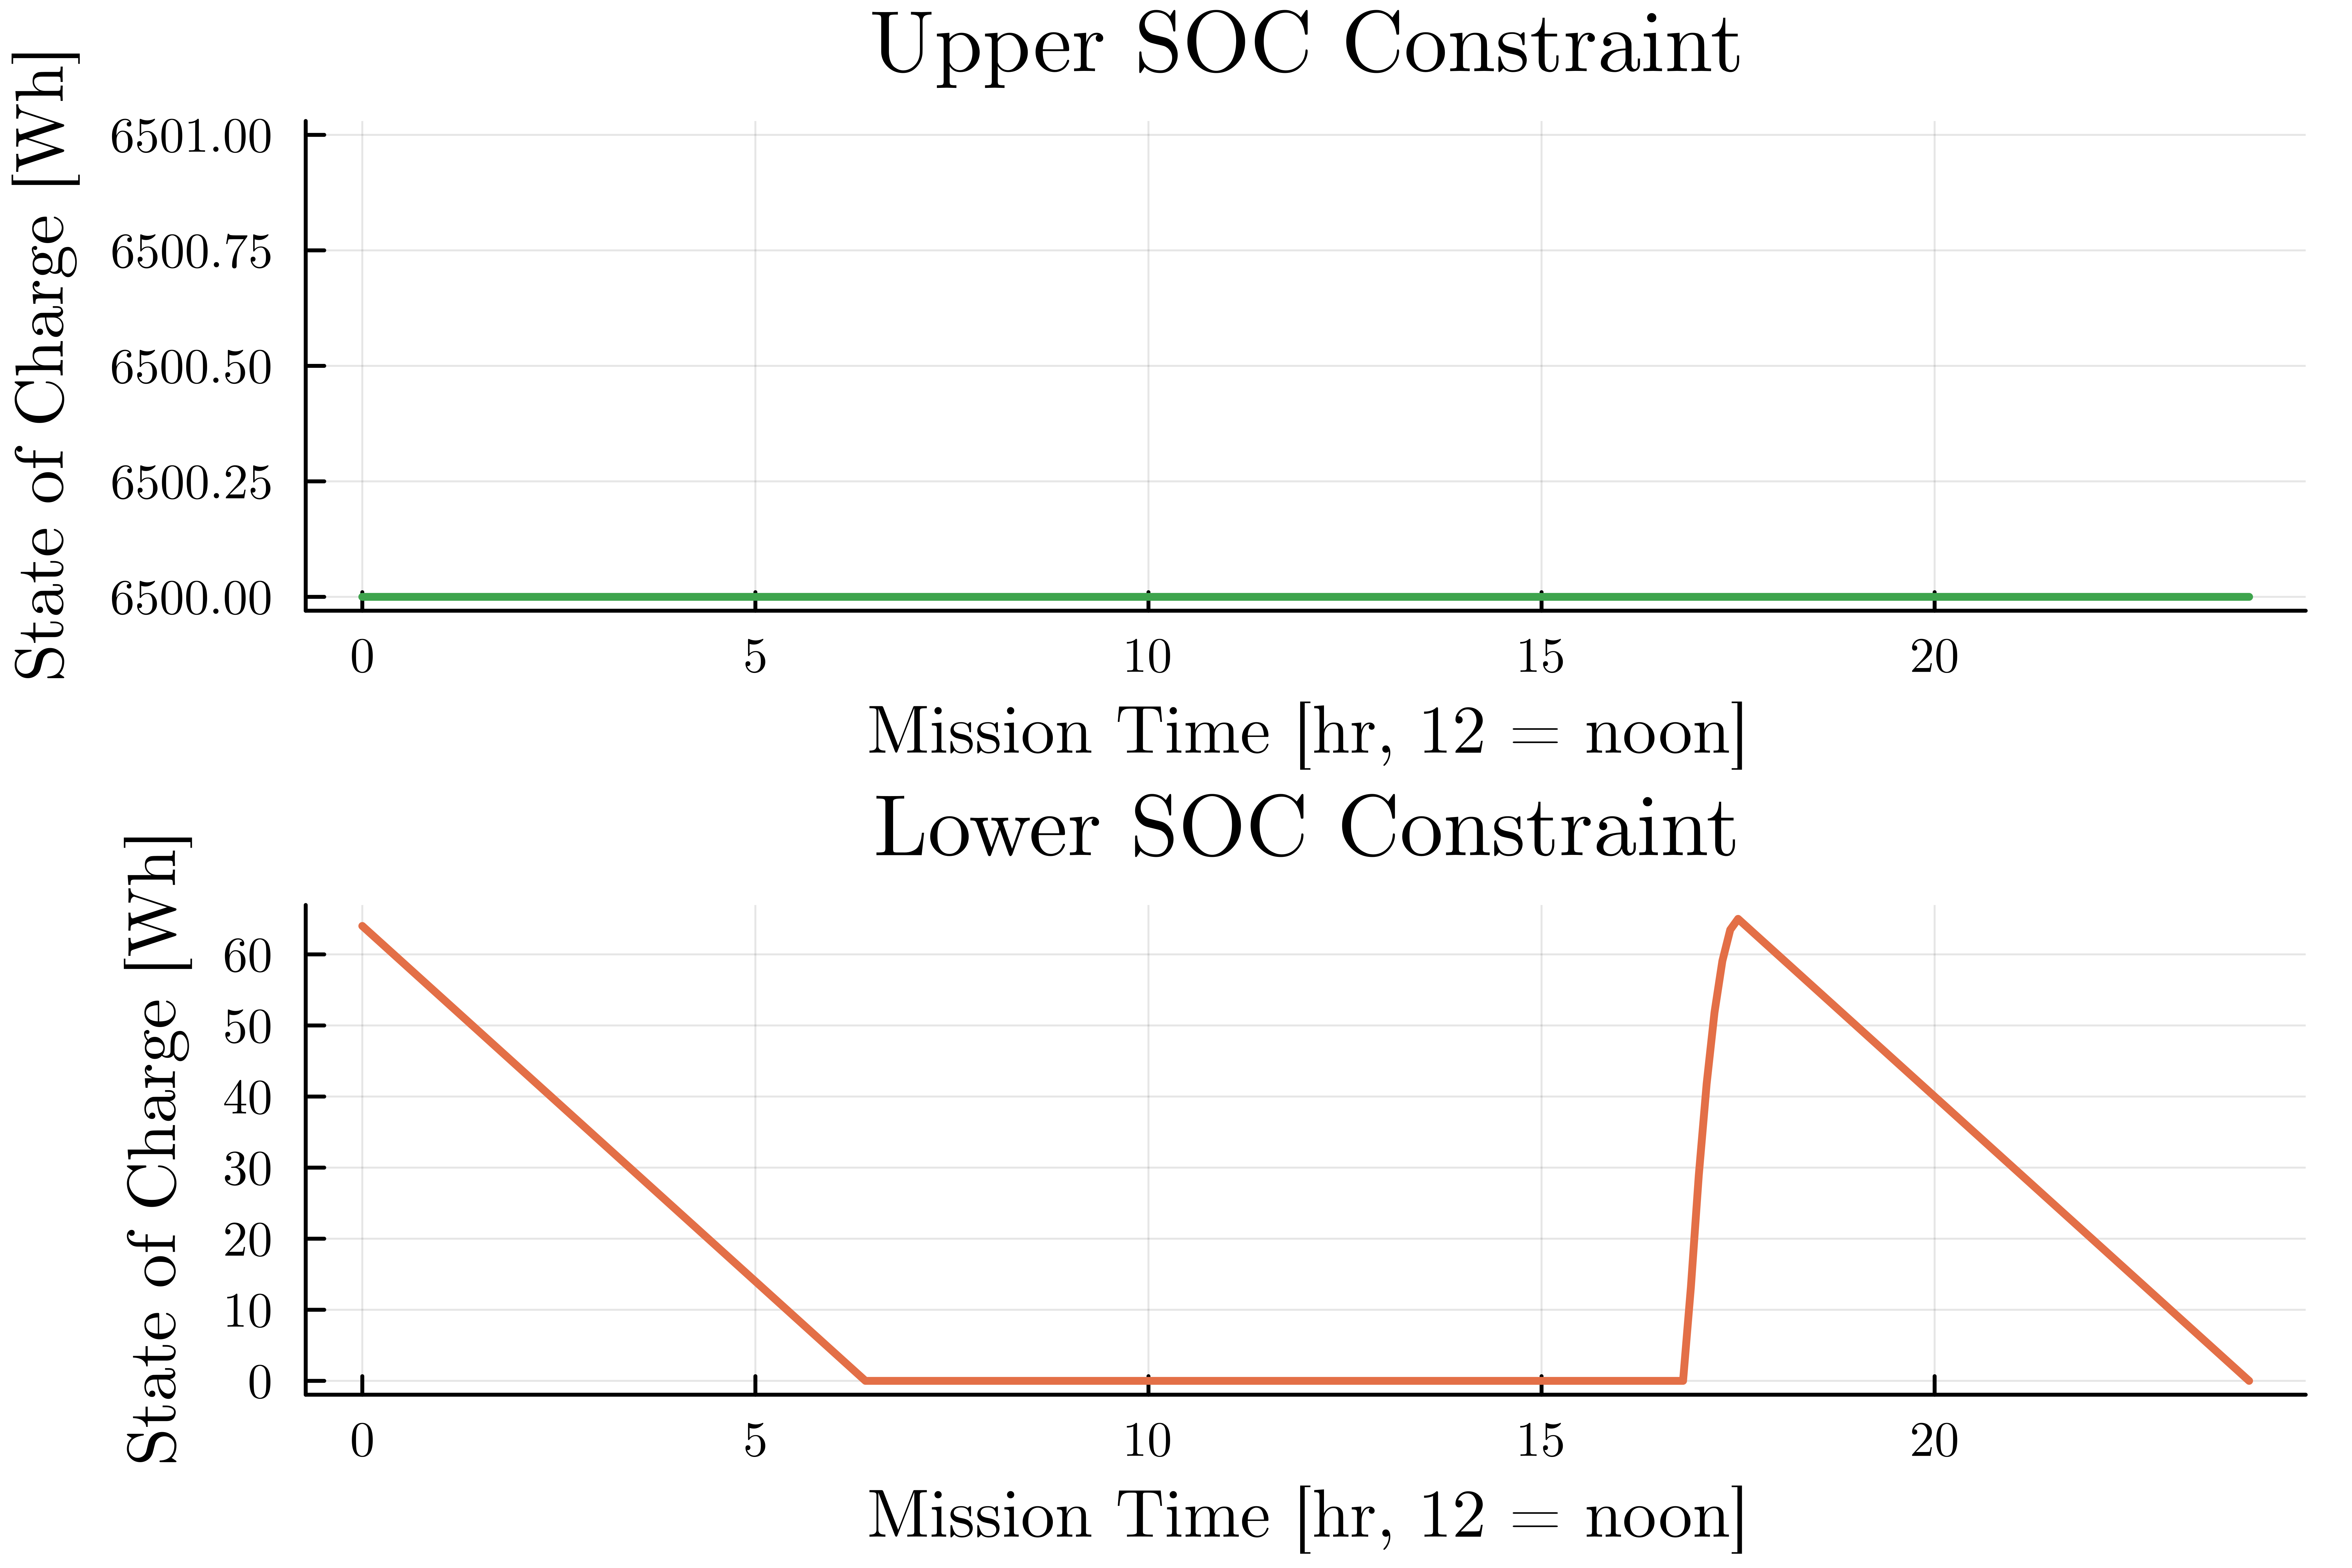

In [8]:
l = @layout[a;b]
plot(
    plot(og_time, ucbf, title="Upper SOC Constraint", color=3, lw=2),
    plot(og_time, lcbf, title="Lower SOC Constraint", color=2, lw=2),
    layout=l,
)

# plot(og_time, [ucbf, lcbf], layout=(2,1), label=false, title=["Upper Constraint", "Lower Constraint"])
xlabel!("Mission Time [hr, 12 = noon]");
ylabel!("State of Charge [Wh]");
plot!(legend=false, dpi=1200)

# Target SOC Profile
We seek to generate an SOC profile. We provide:
- Initial SOC
- Terminal SOC target

We proved in prior work that the optimal speed is a constant one. We also developed the SOC constraint behavior (constraints generated above) in prior work.

Therefore, our target SOC profile will be the one associated with a constant speed that satisfies the initial and terminal SOC constraints.

p2min: 0.000749374
xmax:0
xmax:83160.2050450658
xmax:83160.2050450658
xmax:84218.87973980805
xmax:85689.25308385852
xmax:87740.59781313658
xmax:90638.7344322366
xmax:94732.77728413463
xmax:100496.55341049506
xmax:108475.31850037976
xmax:119275.32170531251
xmax:133506.3316107201
xmax:152991.79630380165
xmax:152991.79630380165
xmax:152991.79630380165
xmax:152991.79630380165
xmax:152991.79630380165
xmax:152991.79630380165
xmax:156446.45507422148


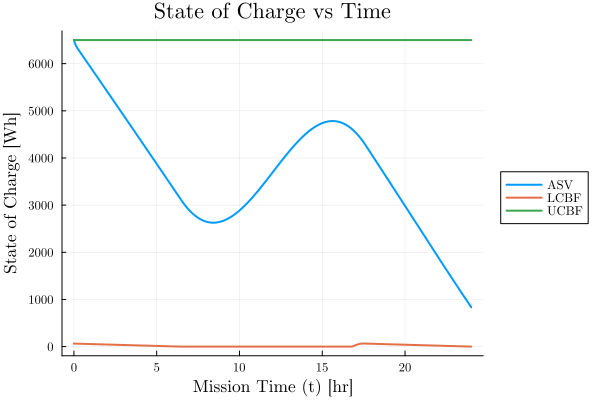

In [10]:
function batterymodel!(boat, dayOfYear, time, lat, vel, soc, dt)
    # Solar Insolation returns in kW
    p_in = max(0,SolarInsolation(dayOfYear, time, lat))* 1000 * boat.panel_area * boat.panel_efficiency;
    p_out = boat.k_h + boat.k_m * (vel^3);
    soc_est = soc + (p_in - p_out)*dt; # power update in Wh
    soc_est = min(soc_est, boat.b_max); # cap charge at soc_max
    return soc_est;
end

function powermodel!(boat, dayOfYear, time, lat, vel, soc, dt)
    # Solar Insolation returns in kW
    p_in = max(0,SolarInsolation(dayOfYear, time, lat))* 1000 * boat.panel_area * boat.panel_efficiency;
    p_out = boat.k_h + boat.k_m * (vel^3);
    out = p_in - p_out;
    return out;
end

function zeropower!(boat, dayOfYear, time, lat, soc, dt)
    p_in = max(0,SolarInsolation(dayOfYear, time, lat))* 1000 * boat.panel_area * boat.panel_efficiency;
    if p_in < boat.k_h
        vel = 0;
    else
        vel = cbrt((p_in - boat.k_h)/boat.k_m);
    end
    return vel;
end




function generate_SOC_target(lcbf, ucbf)
    # Learning gains
    k_p = -5e-5; # Learning P gain (-1e-5)
    k_d = -1e-5; # Learning D gain 5e-5 -1e-5


    # Terminal SOC Target
    soc_target = 1000; #Wh


    xmax = 0; # best distance travel
    pstar = 0;
    num_iters = 5000;
    p_list = zeros(num_iters);
    p2_list = zeros(n);
    error_list = zeros(num_iters);
    error_rate = zeros(num_iters);
    p_list[1] = 0.5; # Initial guess for p2
    p2min = 1/(3*boat.k_m*(boat.v_max^2));
    println("p2min: ", p2min);

    δ = 150; # 50Wh barrier on lcbf
    lcbf_dot = diff(lcbf); # Derivative of lcbf

    x = zeros(n);
    b = ones(n)*b_0;
    v = ones(n)*boat.v_max;
    old_b = zeros(n);

    for day = 1:1:num_iters
        println("xmax:$(xmax)")
        x = zeros(n);
        b = ones(n)*b_0;
        v = ones(n)*boat.v_max;

        p2 = p_list[day];

        for j in 2:n
            i = j-1;
            if i == 1 # initial conditions
                x[i] = 0;
                b[i] = b_0;
            end

            p2_list[i] = p2;

            # println(p2);
            # Compute unconstrained velocity and SOC
            v[i] = sqrt(1/(3 * p2 * boat.k_m)); # removed negative sign from numerator to let p be positive
            b_dot = powermodel!(boat, dayOfYear, t[i], lat, v[i], b[i], Δt);

            # Impose Boundary Conditions
            if b[i] <= lcbf[i]
                v[i] = 0;
            elseif 0 < (b[i] - lcbf[i]) < δ
                v[i] = (b[i] - lcbf[i])/δ * v[i] + (1 - (b[i] - lcbf[i])/δ) * boat.v_min;
            elseif b[i] >= ucbf[i]
                v[i] = boat.v_max;
            elseif 0 < (ucbf[i] - b[i]) < δ
                v[i] = (ucbf[i] - b[i])/δ * v[i] + (1 - (ucbf[i] - b[i])/δ) * boat.v_max;
            end

            # Move boat
            x[j] = x[i] + (v[i] * 60 * 60) * Δt;
            b[j] = batterymodel!(boat, dayOfYear, t[i], lat, v[i], b[i], Δt);
            v[j] = v[i];

            # Continuous rate update
            if day != 1
                cont_error = b[j] - old_b[j];
                # pbar = log10(p2) + k_d * cont_error;
                pbar = log10(p_list[day-1]) + k_d * cont_error; # update co-state from previous day
                p2 = 10^pbar;
                # println("Day: ", day, "\t Time: ", j, "\t new p2: ", p2);
            end
        end

        # Learning adjustment
        if day < num_iters
            error_rate[day] = 0;
            error_list[day] = b[end] - soc_target;
            if day != 1
                error_rate[day] = error_list[day] - error_list[day-1];
            end
            pbar = log10(p_list[day]) + k_p * error_list[day];
            p_list[day+1] = 10^pbar;
        end

        old_b = b;

        # Find optimal p2 and x
        if x[end] > xmax
            xmax = x[end];
            pstar = p2;
        end

        if abs(b[end] - soc_target) < 500
            break;
        end
    end
    return b
end

b = generate_SOC_target(lcbf, ucbf)


# println("p2 end: ", p_list[end]);

# Plot SOC vs Time
plot(og_time, b, label="ASV");
plot!(og_time, lcbf, label="LCBF");
plot!(og_time, ucbf, label="UCBF");
xlabel!("Mission Time (t) [hr]");
ylabel!("State of Charge [Wh]");
title!("State of Charge vs Time");
plot!(legend=:outerright)

In [17]:
findfirst(p_list .== 0)

21

# SOC Controller
Given the target SOC profile, we now implement a simple low-gain feedback controller to track the SOC profile.

If the real-world solar irradiance profile matches the model we used to generate this trajectory, then our speed profile should be identical to the one used to generate the target SOC profile (i.e a constant velocity, except right at the beginning where we are at the upper constraint).

However, it is highly likely that the real-world irradiance profile will not match the model. Thus, we will need to adjust our velocity in real-time to track this profile.

Some potential issues:
- There exists a portion of charging in the target profile. If there isn't enough solar irradiance, then we will never charge and thus the ASV will sit stationary until we reach a time on the SOC target profile that matches the current state of the ASV.

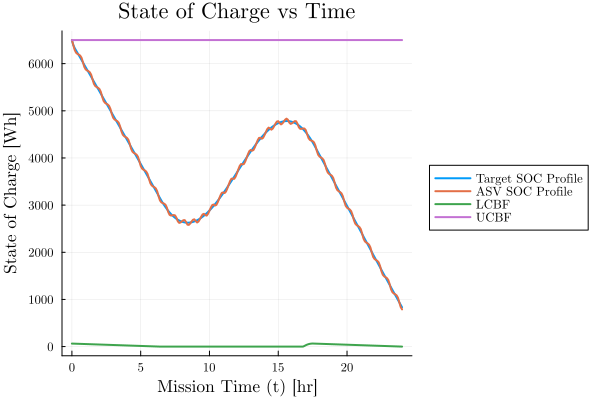

In [18]:
function batterymodel!(boat, dayOfYear, time, lat, vel, soc, dt)
    # Solar Insolation returns in kW
    p_in = max(0,SolarInsolation(dayOfYear, time, lat))* 1000 * boat.panel_area * boat.panel_efficiency;
    p_out = boat.k_h + boat.k_m * (vel^3);
    soc_est = soc + (p_in - p_out)*dt; # power update in Wh
    soc_est = min(soc_est, boat.b_max); # cap charge at soc_max
    return soc_est;
end

function powermodel!(boat, dayOfYear, time, lat, vel, soc, dt)
    # Solar Insolation returns in kW
    p_in = max(0,SolarInsolation(dayOfYear, time, lat))* 1000 * boat.panel_area * boat.panel_efficiency;
    p_out = boat.k_h + boat.k_m * (vel^3);
    out = p_in - p_out;
    return out;
end

function zeropower!(boat, dayOfYear, time, lat, soc, dt)
    p_in = max(0,SolarInsolation(dayOfYear, time, lat))* 1000 * boat.panel_area * boat.panel_efficiency;
    if p_in < boat.k_h
        vel = 0;
    else
        vel = cbrt((p_in - boat.k_h)/boat.k_m);
    end
    return vel;
end


# Store the target profile
soc_profile = b;
soc_kp = 0.01;
soc_kd = 0;

# Create variables to store the ASV's state in this simulation
b_sim = ones(n)*b_0;
v_sim = ones(n)*boat.v_max;
e_sim = zeros(n); # error profile


for j in 2:n
    i = j-1;
    if i == 1 # initial conditions
        b_sim[i] = b_0;
    end

    # Compute error between current soc and target soc
    e_sim[i] = b_sim[i] - soc_profile[i];

    # Compute unconstrained velocity and SOC
    v_sim[i] += soc_kp * e_sim[i] + soc_kd * diff(e_sim)[i]; # removed negative sign from numerator to let p be positive
    b_dot = powermodel!(boat, dayOfYear, t[i], lat, v_sim[i], b_sim[i], Δt);

    # Impose Boundary Conditions
    if b_sim[i] <= lcbf[i]
        v_sim[i] = 0;
    elseif 0 < (b_sim[i] - lcbf[i]) < δ
        v_sim[i] = (b_sim[i] - lcbf[i])/δ * v_sim[i] + (1 - (b_sim[i] - lcbf[i])/δ) * boat.v_min;
    elseif b_sim[i] >= ucbf[i]
        v_sim[i] = boat.v_max;
    elseif 0 < (ucbf[i] - b_sim[i]) < δ
        v_sim[i] = (ucbf[i] - b_sim[i])/δ * v_sim[i] + (1 - (ucbf[i] - b_sim[i])/δ) * boat.v_max;
    end

    # Move boat
    b_sim[j] = batterymodel!(boat, dayOfYear, t[i], lat, v_sim[i], b_sim[i], Δt);
    v_sim[j] = v_sim[i];
end

# Plot SOC vs Time
plot(og_time, soc_profile, label="Target SOC Profile");
plot!(og_time, b_sim, label="ASV SOC Profile");
plot!(og_time, lcbf, label="LCBF");
plot!(og_time, ucbf, label="UCBF");
xlabel!("Mission Time (t) [hr]");
ylabel!("State of Charge [Wh]");
title!("State of Charge vs Time");
plot!(legend=:outerright)

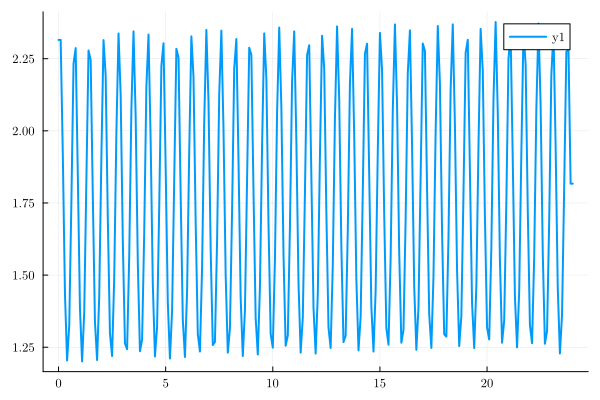

In [19]:
plot(og_time, v_sim)